In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Missing Data

In [3]:
df=pd.read_csv('data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
df.shape

(19158, 13)

In [6]:
cols=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [7]:
df[cols].head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


In [8]:
#=======================================  WORK ON NUMERIC DATA  ==============================================

In [9]:
df[cols].select_dtypes(include=['number'])

,city_development_index,experience,training_hours
0,0.920,20.0,36.0
1,0.776,15.0,47.0
2,0.624,5.0,83.0
3,0.789,0.0,52.0
4,0.767,20.0,8.0
...,...,...,...
19153,0.878,14.0,42.0
19154,0.920,14.0,52.0
19155,0.920,20.0,44.0
19156,0.802,0.0,97.0


In [10]:
# percentage of rows that do not have missing value
len(df[cols].dropna())/len(df)

0.8968577095730244

In [11]:
new_df=df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

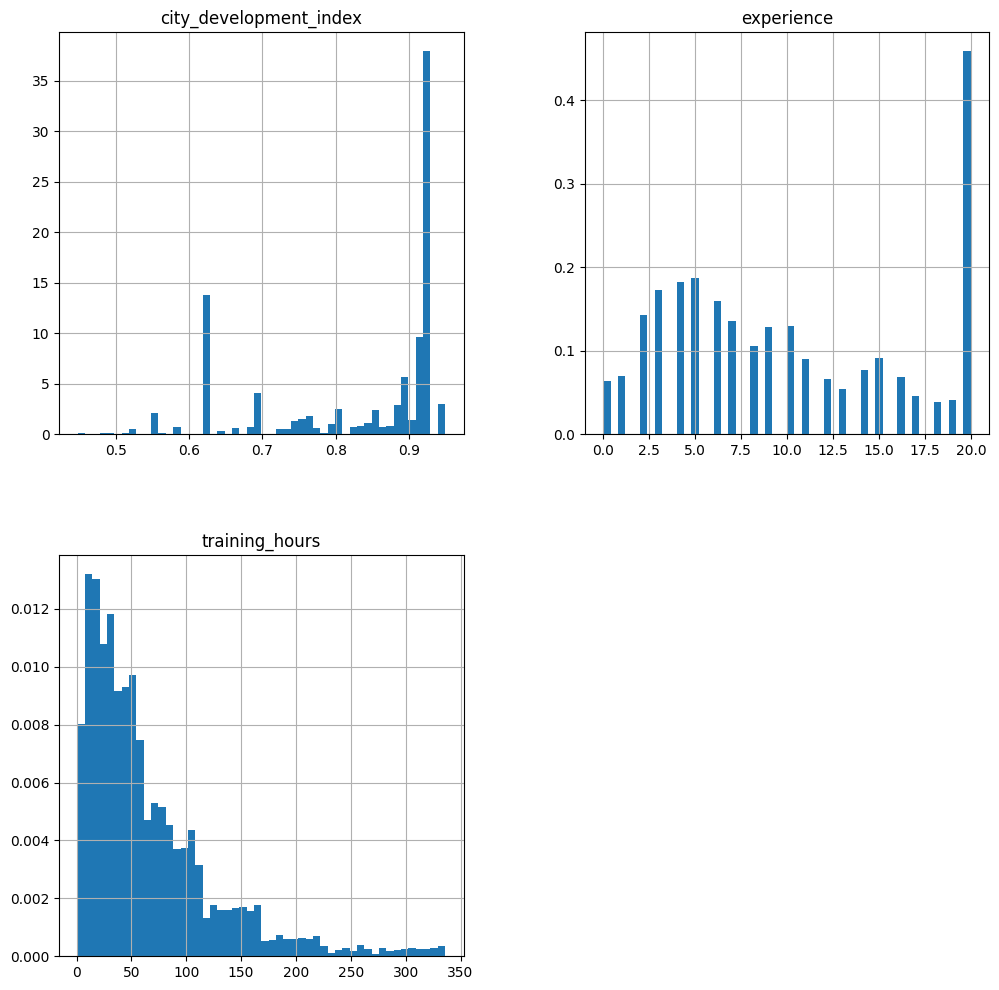

In [12]:
new_df.hist(bins=50,density=True,figsize=(12,12))
plt.show()

<Axes: >

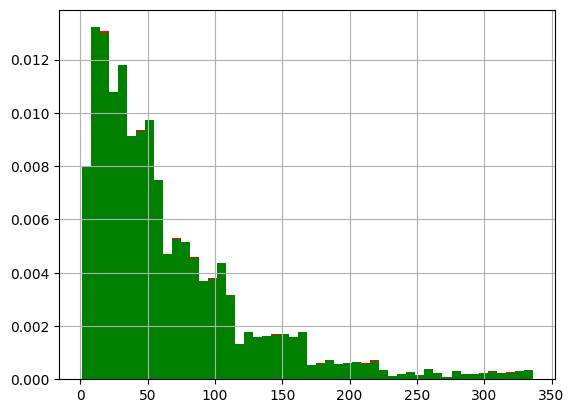

In [13]:
fig=plt.figure()
ax=fig.add_subplot(111) #Create single subplot in 1 figure

#Before CCA
df['training_hours'].hist(bins=50,ax=ax,density=True,color='red')

#After CCA
new_df['training_hours'].hist(bins=50,ax=ax,density=True,color='green')

<Axes: ylabel='Density'>

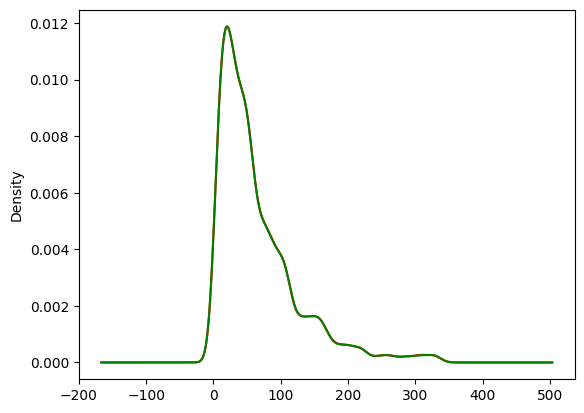

In [14]:
df['training_hours'].plot.density(color='red')
new_df['training_hours'].plot.density(color='green')

<Axes: >

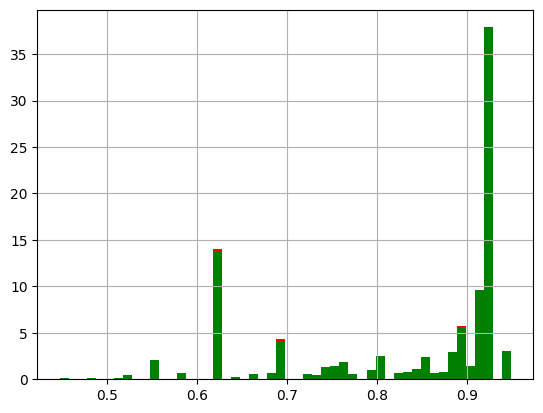

In [15]:
# Appling on city_development index
fig=plt.figure()
ax=fig.add_subplot(111)

df['city_development_index'].hist(bins=50,ax=ax,density=True,color='red')
new_df['city_development_index'].hist(bins=50,ax=ax,density=True,color='green')

<Axes: ylabel='Density'>

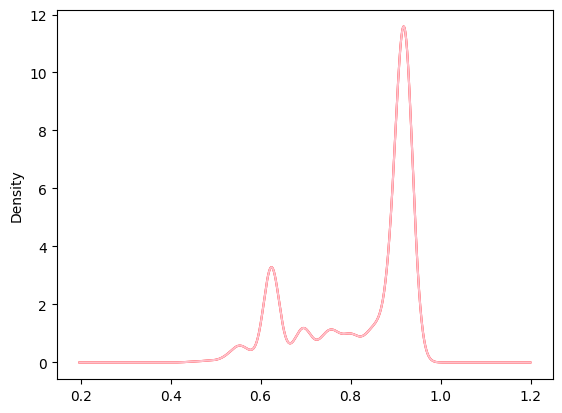

In [16]:
df['city_development_index'].plot.density(color='red')
df['city_development_index'].plot.density(color='pink')

<Axes: >

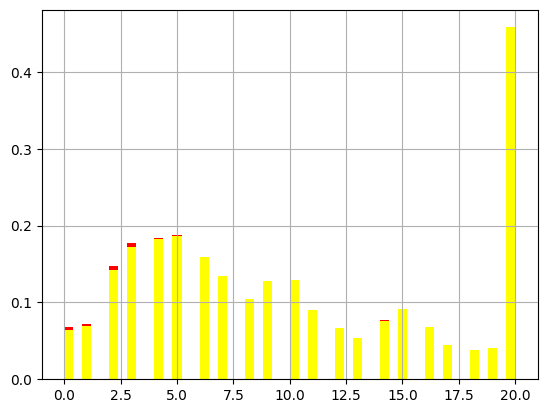

In [17]:
fig=plt.figure()
ax=fig.add_subplot(111)

df['experience'].hist(bins=50,ax=ax,density=True,color='red')
new_df['experience'].hist(bins=50,ax=ax,density=True,color='yellow')

<Axes: ylabel='Density'>

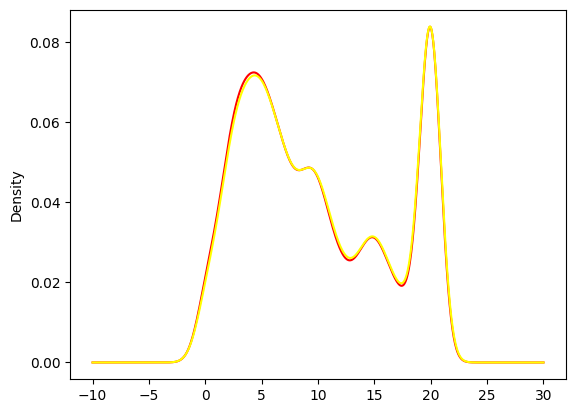

In [18]:
df['experience'].plot.density(color='red')
new_df['experience'].plot.density(color='yellow')

In [19]:
# ==============================  WORK ON CATEGORICAL DATA  ==================================================

In [20]:
df[cols].select_dtypes(include=['object'])

,enrolled_university,education_level
0,no_enrollment,Graduate
1,no_enrollment,Graduate
2,Full time course,Graduate
3,NaN,Graduate
4,no_enrollment,Masters
...,...,...
19153,no_enrollment,Graduate
19154,no_enrollment,Graduate
19155,no_enrollment,Graduate
19156,no_enrollment,High School


In [21]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [22]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [23]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [24]:
temp=pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(df)
],axis=1)

temp.columns=['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [51]:
temp=pd.concat([
    df['education_level'].value_counts() /len(df),
    new_df['education_level'].value_counts() /len(df)
],axis=1)

temp.columns=['original','cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876


# Handling numerical Data

# Using pandas for mean median function

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [64]:
df=pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [66]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [70]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [78]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [80]:
# Mean and median of Age
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

#Mean and median of Fare
mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].mean()


In [88]:
# Filling the Nan values with respective mena and median
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['Age_mean']=X_train['Age'].fillna(mean_age)

X_train['Fare_median']=X_train['Fare'].fillna(median_fare)
X_train['Fare_mean']=X_train['Fare'].fillna(mean_fare)

X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
662,47.0,NaN,0,47.0,47.000000,32.517788,32.517788
540,36.0,71.0000,2,36.0,36.000000,71.000000,71.000000
667,NaN,7.7750,0,28.0,29.498846,7.775000,7.775000
8,27.0,11.1333,2,27.0,27.000000,11.133300,11.133300
606,30.0,7.8958,0,30.0,30.000000,7.895800,7.895800


In [90]:
# Checking for variance before and after applying functions
print("Age variance before using function: ",X_train['Age'].var())
print("Age varience after median: ",X_train['Age_median'].var())
print("Age varience after mean: ",X_train['Age_mean'].var())

print("Fare variance before using function: ",X_train['Fare'].var())
print("Fare variance after median: ",X_train['Fare_median'].var())
print("Fare variance after mean: ",X_train['Fare_mean'].var())


Age variance before using function:  210.2517072477435
Age varience after median:  169.20731007048155
Age varience after mean:  168.85193366872227
Fare variance before using function:  2761.0314349486343
Fare variance after median:  2621.232374951235
Fare variance after mean:  2621.232374951235


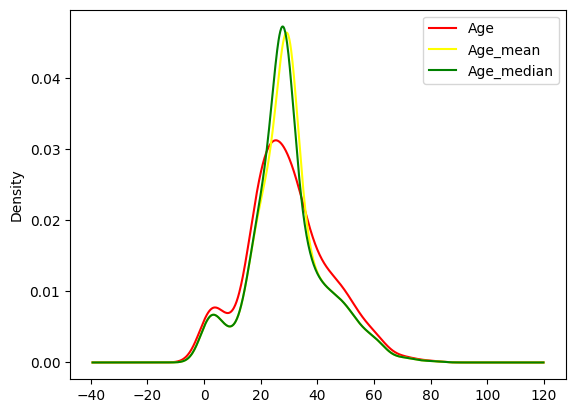

In [96]:
fig=plt.figure()
ax=fig.add_subplot(111)

#Original
X_train['Age'].plot(kind='kde',ax=ax,color='red')

#Mean
X_train['Age_mean'].plot(kind='kde',ax=ax,color='yellow')

#median
X_train['Age_median'].plot(kind='kde',ax=ax,color='green')

#Add legends
lines,labels=ax.get_legend_handles_labels()    #collect plot items
ax.legend(lines,labels,loc='best')            #Display


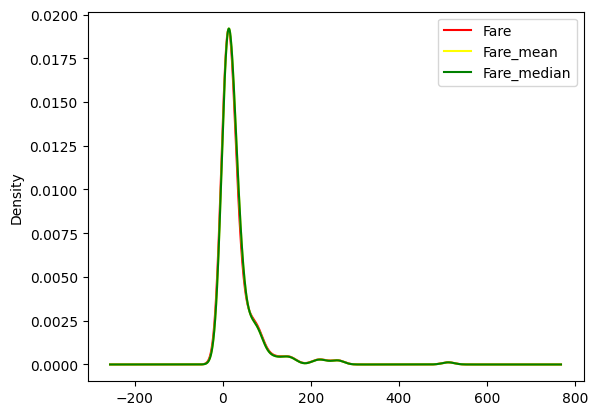

In [102]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax,color='red')
X_train['Fare_mean'].plot(kind='kde',ax=ax,color='yellow')
X_train['Fare_median'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [106]:
X_train.cov()  #More change in value is not good

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.657433,17.657433
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,60.700688,60.700688
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,57.175304
Fare_median,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375
Fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [108]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204981,0.204981
Age_median,1.000000,0.093496,-0.255307,1.000000,0.998949,0.091145,0.091145
Age_mean,1.000000,0.088151,-0.256883,0.998949,1.000000,0.085941,0.085941
Fare_median,0.088944,1.000000,0.204981,0.091145,0.085941,1.000000,1.000000
Fare_mean,0.088944,1.000000,0.204981,0.091145,0.085941,1.000000,1.000000


<Axes: >

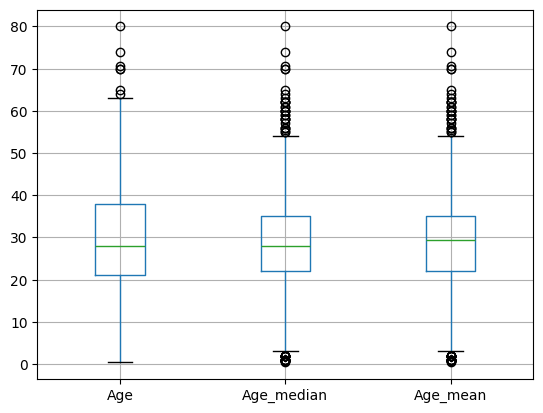

In [114]:
X_train[['Age','Age_median','Age_mean']].boxplot()  #If outlier is increasing as compare to the original one then it is not good

<Axes: >

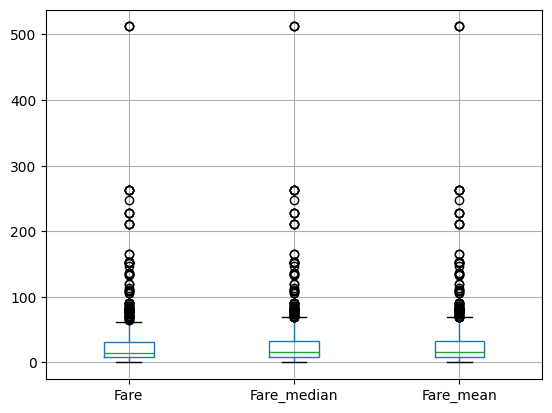

In [112]:
X_train[['Fare','Fare_median','Fare_mean']].boxplot()

# Using sklearn for mean median 

In [144]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [146]:
imputer1=SimpleImputer(strategy='mean')
imputer2=SimpleImputer(strategy='median')

In [148]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [150]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [152]:
trf.named_transformers_['imputer1'].statistics_

array([29.49884615])

In [154]:
trf.named_transformers_['imputer2'].statistics_

array([14.4])

In [156]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [158]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.4   ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))

In [167]:
# ====================================================================================================================================================

# using pandas for arbitary fuction

In [165]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [169]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_-1']=X_train['Age'].fillna(-1)

X_train['Fare_99']=X_train['Fare'].fillna(99)
X_train['Fare_-1']=X_train['Fare'].fillna(-1)

In [186]:
X_train.sample(5)

,Age,Fare,Family,Age_99,Age_-1,Fare_99,Fare_-1
146,27.0,7.7958,0,27.0,27.0,7.7958,7.7958
719,33.0,7.7750,0,33.0,33.0,7.7750,7.7750
429,32.0,NaN,0,32.0,32.0,99.0000,-1.0000
381,1.0,15.7417,2,1.0,1.0,15.7417,15.7417
756,28.0,7.7958,0,28.0,28.0,7.7958,7.7958


In [188]:
# Checking for variance before and after applying functions
print("Age variance before using function: ",X_train['Age'].var())
print("Age varience after median: ",X_train['Age_99'].var())
print("Age varience after mean: ",X_train['Age_-1'].var())

print("Fare variance before using function: ",X_train['Fare'].var())
print("Fare variance after median: ",X_train['Fare_99'].var())
print("Fare variance after mean: ",X_train['Fare_-1'].var())

Age variance before using function:  210.2517072477435
Age varience after median:  932.9665366701432
Age varience after mean:  315.9955036260055
Fare variance before using function:  2761.0314349486343
Fare variance after median:  2833.708690936761
Fare variance after mean:  2675.2394049177024


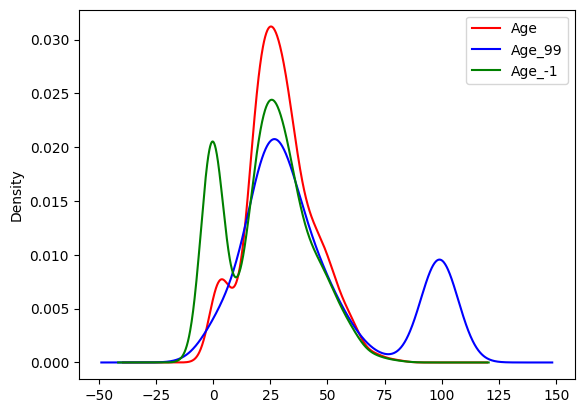

In [190]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax,color='red')
X_train['Age_99'].plot(kind='kde',ax=ax,color='blue')
X_train['Age_-1'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

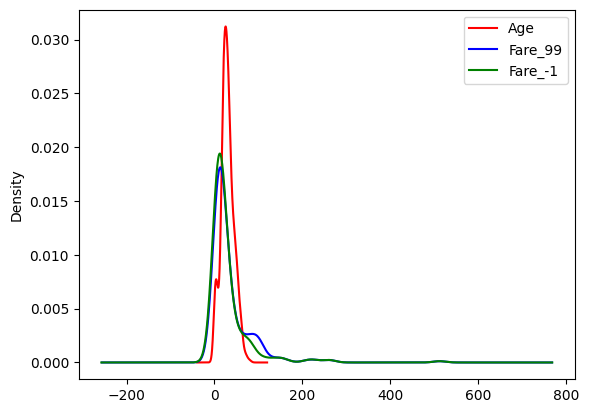

In [192]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax,color='red')
X_train['Fare_99'].plot(kind='kde',ax=ax,color='blue')
X_train['Fare_-1'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [194]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_-1,Fare_99,Fare_-1
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.091016,0.085422
Fare,0.091482,1.000000,0.207193,-0.069365,0.145071,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.135079,-0.168329,0.196548,0.203212
Age_99,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.071667,-0.064017
Age_-1,1.000000,0.145071,-0.168329,-0.306576,1.000000,0.145956,0.135159
Fare_99,0.091016,1.000000,0.196548,-0.071667,0.145956,1.000000,0.913115
Fare_-1,0.085422,1.000000,0.203212,-0.064017,0.135159,0.913115,1.000000


In [196]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_-1,Fare_99,Fare_-1
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,75.273024,69.137162
Fare,75.481375,2761.031435,18.599163,-111.965046,135.785804,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-6.941982,-5.034556,17.603852,17.684447
Age_99,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-116.528480,-101.137070
Age_-1,210.251707,135.785804,-5.034556,-166.460682,315.995504,138.114503,124.270305
Fare_99,75.273024,2761.031435,17.603852,-116.528480,138.114503,2833.708691,2514.109946
Fare_-1,69.137162,2761.031435,17.684447,-101.137070,124.270305,2514.109946,2675.239405


# Using sklearn for arbitary function

In [199]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [201]:
imputer1=SimpleImputer(strategy='constant',fill_value=99)
imputer2=SimpleImputer(strategy='constant',fill_value=-1)

In [213]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [215]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [217]:
trf.named_transformers_['imputer1'].statistics_

array([99], dtype=object)

In [219]:
trf.named_transformers_['imputer2'].statistics_

array([-1], dtype=object)

In [221]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [225]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  -1.    ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))